# Collaborative Filtering Implementation
## Movie Recommendation System - Warm Start Evaluation

This notebook contains the implementation of three collaborative filtering algorithms:
1. **Item-Based Collaborative Filtering**
2. **User-Based Collaborative Filtering**
3. **SVD Matrix Factorization**

Each algorithm is evaluated on both **Random Split** and **Temporal Split** strategies for warm start scenarios (where both user and movie exist in training data).

## 1. Imports and Setup

In [82]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Sklearn utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print(" Basic imports loaded")

 Basic imports loaded


In [83]:
# Collaborative filtering specific imports
from scipy.sparse import csr_matrix, lil_matrix
from scipy.sparse.linalg import svds
from sklearn.metrics.pairwise import cosine_similarity
from tqdm.notebook import tqdm
import gc
import warnings
warnings.filterwarnings('ignore')

print(" Collaborative filtering imports loaded")

 Collaborative filtering imports loaded


## 2. Utility Functions

Core helper functions for data preparation, evaluation, and filtering.

In [84]:
def create_id_mappings(ratings_df):
    """
    Create mappings from original IDs to 0-indexed matrix indices.
    
    Args:
        ratings_df: DataFrame with 'userId' and 'movieId' columns
        
    Returns:
        user_id_map: dict mapping userId -> matrix row index
        movie_id_map: dict mapping movieId -> matrix column index
    """
    unique_users = ratings_df['userId'].unique()
    unique_movies = ratings_df['movieId'].unique()
    
    user_id_map = {user_id: idx for idx, user_id in enumerate(unique_users)}
    movie_id_map = {movie_id: idx for idx, movie_id in enumerate(unique_movies)}
    
    print(f"Created mappings: {len(user_id_map)} users, {len(movie_id_map)} movies")
    return user_id_map, movie_id_map


def create_sparse_matrix(ratings_df, user_id_map, movie_id_map):
    """
    Create sparse CSR matrix from ratings DataFrame.
    
    Args:
        ratings_df: DataFrame with 'userId', 'movieId', 'rating' columns
        user_id_map: dict mapping userId -> row index
        movie_id_map: dict mapping movieId -> column index
        
    Returns:
        csr_matrix: Sparse user-item matrix (users × movies)
    """
    n_users = len(user_id_map)
    n_movies = len(movie_id_map)
    
    # Map IDs to indices
    row_indices = ratings_df['userId'].map(user_id_map).values
    col_indices = ratings_df['movieId'].map(movie_id_map).values
    ratings = ratings_df['rating'].values
    
    # Create sparse matrix
    sparse_matrix = csr_matrix(
        (ratings, (row_indices, col_indices)),
        shape=(n_users, n_movies)
    )
    
    sparsity = 100 * (1 - sparse_matrix.nnz / (n_users * n_movies))
    print(f"Sparse matrix: {sparse_matrix.shape}, {sparse_matrix.nnz:,} ratings, {sparsity:.2f}% sparse")
    
    return sparse_matrix


def calculate_metrics(actual, predicted):
    """
    Calculate RMSE and MAE metrics.
    
    Args:
        actual: array-like of actual ratings
        predicted: array-like of predicted ratings
        
    Returns:
        dict with 'rmse' and 'mae' keys
    """
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    return {'rmse': rmse, 'mae': mae}


def filter_warm_start(test_df, train_df):
    """
    Filter test set to warm start cases only (both user and movie seen in training).
    
    Args:
        test_df: Test DataFrame
        train_df: Training DataFrame
        
    Returns:
        DataFrame with only warm start test cases
    """
    train_users = set(train_df['userId'].unique())
    train_movies = set(train_df['movieId'].unique())
    
    warm_start_test = test_df[
        test_df['userId'].isin(train_users) & 
        test_df['movieId'].isin(train_movies)
    ].copy()
    
    print(f"Warm start: {len(warm_start_test):,} / {len(test_df):,} test cases ({100*len(warm_start_test)/len(test_df):.1f}%)")
    return warm_start_test


print("✓ Utility functions defined")

✓ Utility functions defined


## 3. Data Loading and Preparation

Load the preprocessed train/test splits and create data structures for warm start evaluation.

**Evaluation Strategy**: We evaluate on BOTH split types to compare performance:
- **Random Split (80/20)**: Random train/test split (no temporal ordering)
- **Temporal Split (80/20)**: Train on past (1995-2015), test on future (2015-2017)

**Warm Start Focus**: Both user and movie must exist in training set for all test cases evaluated.

**Data Structure**:
```
./data/
├── raw/                          # Original datasets
│   ├── ratings.csv
│   ├── movies_metadata.csv
│   ├── credits.csv
│   ├── keywords.csv
│   └── links.csv
└── processed/                    # Cleaned datasets
    ├── cleaned_ratings.csv
    ├── cleaned_movies_metadata.csv
    ├── cleaned_credits.csv
    ├── cleaned_keywords.csv
    ├── cleaned_links.csv
    ├── random_split/
    │   ├── train_ratings.csv
    │   └── test_ratings.csv
    └── temporal_split/
        ├── train_ratings.csv
        └── test_ratings.csv
```

### 3.1 Data Configuration

In [85]:
import os

# Define data directories (relative to notebook location)
RAW_DATA_DIR = './data/raw/'
PROCESSED_DATA_DIR = './data/processed/'

# Sample size for evaluation (applies to both warm and cold start)
SAMPLE_SIZE = 100000  # Adjust as needed for faster experimentation

print(" Data paths and configuration set")

 Data paths and configuration set


### 3.2 Random Split (80/20) - Data Loading

Load random 80/20 split (no temporal ordering). This represents the baseline where train/test are randomly shuffled.

In [86]:
# Load RANDOM split data
random_train_path = os.path.join(PROCESSED_DATA_DIR, 'random_split', 'train_ratings.csv')
random_test_path = os.path.join(PROCESSED_DATA_DIR, 'random_split', 'test_ratings.csv')

print("Loading RANDOM split data...")
print(f"  Train: {random_train_path}")
print(f"  Test:  {random_test_path}\n")

random_train = pd.read_csv(random_train_path)
random_test = pd.read_csv(random_test_path)

print(f"Training set: {len(random_train):,} ratings")
print(f"Test set: {len(random_test):,} ratings")
print(f"\nTrain users: {random_train['userId'].nunique():,}")
print(f"Train movies: {random_train['movieId'].nunique():,}")

Loading RANDOM split data...
  Train: ./data/processed/random_split/train_ratings.csv
  Test:  ./data/processed/random_split/test_ratings.csv

Training set: 20,819,431 ratings
Test set: 5,204,858 ratings

Train users: 269,710
Train movies: 43,326


In [87]:
# Create ID mappings for RANDOM split
random_user_id_map, random_movie_id_map = create_id_mappings(random_train)

# Create reverse mappings (index -> original ID)
random_idx_to_user = {idx: user_id for user_id, idx in random_user_id_map.items()}
random_idx_to_movie = {idx: movie_id for movie_id, idx in random_movie_id_map.items()}

Created mappings: 269710 users, 43326 movies


In [88]:
# Create sparse user-item matrix for RANDOM split (raw ratings)
random_user_item_matrix = create_sparse_matrix(random_train, random_user_id_map, random_movie_id_map)

# Calculate global mean rating (for fallback predictions)
random_global_mean = random_train['rating'].mean()
print(f"\nGlobal mean rating: {random_global_mean:.3f}")

Sparse matrix: (269710, 43326), 20,819,431 ratings, 99.82% sparse

Global mean rating: 3.528


In [89]:
# Filter RANDOM test set to warm start cases only
random_test_warm = filter_warm_start(random_test, random_train)

# Sample for faster experimentation
if len(random_test_warm) > SAMPLE_SIZE:
    random_test_warm_sample = random_test_warm.sample(n=SAMPLE_SIZE, random_state=42)
    print(f"\nUsing sample of {SAMPLE_SIZE:,} test cases for evaluation")
else:
    random_test_warm_sample = random_test_warm
    print(f"\nUsing all {len(random_test_warm):,} warm start test cases")

Warm start: 5,201,367 / 5,204,858 test cases (99.9%)

Using sample of 100,000 test cases for evaluation


### 3.3 Temporal Split (80/20) - Data Loading

Load temporal split (train on past 1995-2015, test on future 2015-2017). This simulates real-world production scenarios where we predict future ratings.

In [90]:
# Load TEMPORAL split data
temporal_train_path = os.path.join(PROCESSED_DATA_DIR, 'temporal_split', 'train_ratings.csv')
temporal_test_path = os.path.join(PROCESSED_DATA_DIR, 'temporal_split', 'test_ratings.csv')

print("Loading TEMPORAL split data...")
print(f"  Train: {temporal_train_path}")
print(f"  Test:  {temporal_test_path}\n")

temporal_train = pd.read_csv(temporal_train_path)
temporal_test = pd.read_csv(temporal_test_path)

print(f"Training set: {len(temporal_train):,} ratings")
print(f"Test set: {len(temporal_test):,} ratings")
print(f"\nTrain users: {temporal_train['userId'].nunique():,}")
print(f"Train movies: {temporal_train['movieId'].nunique():,}")

Loading TEMPORAL split data...
  Train: ./data/processed/temporal_split/train_ratings.csv
  Test:  ./data/processed/temporal_split/test_ratings.csv

Training set: 20,819,431 ratings
Test set: 5,204,858 ratings

Train users: 227,222
Train movies: 25,636


In [91]:
# Create ID mappings for TEMPORAL split
temporal_user_id_map, temporal_movie_id_map = create_id_mappings(temporal_train)

# Create reverse mappings (index -> original ID)
temporal_idx_to_user = {idx: user_id for user_id, idx in temporal_user_id_map.items()}
temporal_idx_to_movie = {idx: movie_id for movie_id, idx in temporal_movie_id_map.items()}

Created mappings: 227222 users, 25636 movies


In [92]:
# Create sparse user-item matrix for TEMPORAL split (raw ratings)
temporal_user_item_matrix = create_sparse_matrix(temporal_train, temporal_user_id_map, temporal_movie_id_map)

# Calculate global mean rating (for fallback predictions)
temporal_global_mean = temporal_train['rating'].mean()
print(f"\nGlobal mean rating: {temporal_global_mean:.3f}")

Sparse matrix: (227222, 25636), 20,819,431 ratings, 99.64% sparse

Global mean rating: 3.521


In [93]:
# Filter TEMPORAL test set to warm start cases only
temporal_test_warm = filter_warm_start(temporal_test, temporal_train)

# Sample for faster experimentation
if len(temporal_test_warm) > SAMPLE_SIZE:
    temporal_test_warm_sample = temporal_test_warm.sample(n=SAMPLE_SIZE, random_state=42)
    print(f"\nUsing sample of {SAMPLE_SIZE:,} test cases for evaluation")
else:
    temporal_test_warm_sample = temporal_test_warm
    print(f"\nUsing all {len(temporal_test_warm):,} warm start test cases")

Warm start: 467,049 / 5,204,858 test cases (9.0%)

Using sample of 100,000 test cases for evaluation


## 4. Shared Prediction Functions

These functions work with both random and temporal splits by accepting data structures as parameters.

In [94]:
### 4.1 Item-Based Collaborative Filtering Functions

def compute_item_similarity(user_item_matrix):
    """
    Compute item-item cosine similarity matrix.
    
    Args:
        user_item_matrix: Sparse CSR matrix (users × movies)
        
    Returns:
        Sparse item similarity matrix (movies × movies)
    """
    print("Computing item-item similarity matrix...")
    item_similarity = cosine_similarity(user_item_matrix.T, dense_output=False)
    print(f"Item similarity matrix: {item_similarity.shape}")
    print(f"Sparsity: {100 * (1 - item_similarity.nnz / np.prod(item_similarity.shape)):.2f}%")
    return item_similarity


def predict_rating_item_based(user_id, movie_id, user_id_map, movie_id_map, 
                                user_item_matrix, item_similarity, global_mean, k=30):
    """
    Predict rating using item-based collaborative filtering.
    
    Args:
        user_id: Original user ID
        movie_id: Original movie ID
        user_id_map: dict mapping userId -> matrix row index
        movie_id_map: dict mapping movieId -> matrix column index
        user_item_matrix: Sparse CSR matrix (users × movies)
        item_similarity: Sparse item similarity matrix
        global_mean: Global mean rating for fallback
        k: Number of similar items to consider
        
    Returns:
        Predicted rating (float)
    """
    # Check if user and movie are in training set
    if user_id not in user_id_map or movie_id not in movie_id_map:
        return global_mean
    
    user_idx = user_id_map[user_id]
    movie_idx = movie_id_map[movie_id]
    
    # Get user's ratings (sparse row)
    user_ratings = user_item_matrix.getrow(user_idx)
    
    # Get similarity scores for target movie
    movie_similarities = item_similarity.getrow(movie_idx).toarray().flatten()
    
    # Find top-k similar items that user has rated
    rated_indices = user_ratings.nonzero()[1]
    
    if len(rated_indices) == 0:
        return global_mean
    
    # Get similarities and ratings for rated items
    similarities = movie_similarities[rated_indices]
    ratings = user_ratings.toarray().flatten()[rated_indices]
    
    # Exclude the target movie itself if user has rated it
    mask = rated_indices != movie_idx
    similarities = similarities[mask]
    ratings = ratings[mask]
    
    if len(similarities) == 0:
        return global_mean
    
    # Select top-k most similar items
    top_k_indices = np.argsort(similarities)[-k:]
    top_k_similarities = similarities[top_k_indices]
    top_k_ratings = ratings[top_k_indices]
    
    # Weighted average
    if top_k_similarities.sum() == 0:
        return global_mean
    
    prediction = np.dot(top_k_similarities, top_k_ratings) / top_k_similarities.sum()
    
    # Clip to valid rating range
    return np.clip(prediction, 0.5, 5.0)


print(" Item-based CF functions defined")

 Item-based CF functions defined


### 4.2 User-Based Collaborative Filtering Functions

In [95]:
def mean_center_matrix(user_item_matrix, user_id_map):
    """
    Create mean-centered rating matrix and user means dictionary.
    
    Args:
        user_item_matrix: Sparse CSR matrix (users × movies)
        user_id_map: dict mapping userId -> matrix row index
        
    Returns:
        user_item_matrix_centered: Mean-centered sparse matrix
        user_means: dict mapping userId -> mean rating
    """
    print("Mean-centering ratings...")
    
    # Calculate user means
    user_means = {}
    global_mean = user_item_matrix.data.mean()
    
    for user_id, user_idx in user_id_map.items():
        user_ratings = user_item_matrix.getrow(user_idx).data
        if len(user_ratings) > 0:
            user_means[user_id] = user_ratings.mean()
        else:
            user_means[user_id] = global_mean
    
    # Create mean-centered matrix
    user_item_matrix_centered = user_item_matrix.copy().tolil()
    
    for user_id, user_idx in tqdm(user_id_map.items(), desc="Mean-centering"):
        rated_indices = user_item_matrix.getrow(user_idx).nonzero()[1]
        if len(rated_indices) > 0:
            current_ratings = user_item_matrix[user_idx, rated_indices].toarray().flatten()
            centered_ratings = current_ratings - user_means[user_id]
            for i, movie_idx in enumerate(rated_indices):
                user_item_matrix_centered[user_idx, movie_idx] = centered_ratings[i]
    
    user_item_matrix_centered = user_item_matrix_centered.tocsr()
    print(" Mean-centered matrix created")
    
    return user_item_matrix_centered, user_means


def compute_cosine_similarity_users(user_idx_1, user_idx_2, user_item_matrix_centered):
    """
    Compute cosine similarity between two users (on-demand, memory efficient).
    
    Args:
        user_idx_1: First user's matrix index
        user_idx_2: Second user's matrix index
        user_item_matrix_centered: Mean-centered sparse matrix
        
    Returns:
        Cosine similarity (float)
    """
    vec1 = user_item_matrix_centered.getrow(user_idx_1).toarray().flatten()
    vec2 = user_item_matrix_centered.getrow(user_idx_2).toarray().flatten()
    
    norm1 = np.linalg.norm(vec1)
    norm2 = np.linalg.norm(vec2)
    
    if norm1 == 0 or norm2 == 0:
        return 0.0
    
    return np.dot(vec1, vec2) / (norm1 * norm2)


def predict_rating_user_based(user_id, movie_id, user_id_map, movie_id_map, 
                                user_item_matrix, user_item_matrix_centered, 
                                user_means, global_mean, k=30, max_candidates=100):
    """
    Predict rating using user-based collaborative filtering (memory-optimized).

    Args:
        user_id: Original user ID
        movie_id: Original movie ID
        user_id_map: dict mapping userId -> matrix row index
        movie_id_map: dict mapping movieId -> matrix column index
        user_item_matrix: Sparse CSR matrix (users × movies, raw ratings)
        user_item_matrix_centered: Mean-centered sparse matrix
        user_means: dict mapping userId -> mean rating
        global_mean: Global mean rating for fallback
        k: Number of similar users to consider
        max_candidates: Maximum candidate users to prevent slowdown

    Returns:
        Predicted rating (float)
    """
    if user_id not in user_id_map or movie_id not in movie_id_map:
        return global_mean

    user_idx = user_id_map[user_id]
    movie_idx = movie_id_map[movie_id]

    users_who_rated = user_item_matrix.getcol(movie_idx).nonzero()[0]

    if len(users_who_rated) == 0:
        return user_means.get(user_id, global_mean)

    users_who_rated = users_who_rated[users_who_rated != user_idx]

    if len(users_who_rated) == 0:
        return user_means.get(user_id, global_mean)

    if len(users_who_rated) > max_candidates:
        np.random.seed(42)
        users_who_rated = np.random.choice(users_who_rated, max_candidates, replace=False)

    similarities = []
    ratings_centered = []

    for other_user_idx in users_who_rated:
        sim = compute_cosine_similarity_users(user_idx, other_user_idx, user_item_matrix_centered)
        if sim > 0:
            similarities.append(sim)
            rating_centered = user_item_matrix_centered[other_user_idx, movie_idx]
            ratings_centered.append(rating_centered)

    if len(similarities) == 0:
        return user_means.get(user_id, global_mean)

    similarities = np.array(similarities)
    ratings_centered = np.array(ratings_centered)

    if len(similarities) > k:
        top_k_indices = np.argsort(similarities)[-k:]
        top_k_similarities = similarities[top_k_indices]
        top_k_ratings_centered = ratings_centered[top_k_indices]
    else:
        top_k_similarities = similarities
        top_k_ratings_centered = ratings_centered

    if top_k_similarities.sum() == 0:
        return user_means.get(user_id, global_mean)

    prediction_centered = np.dot(top_k_similarities, top_k_ratings_centered) / top_k_similarities.sum()
    prediction = prediction_centered + user_means.get(user_id, global_mean)

    return np.clip(prediction, 0.5, 5.0)


print(" User-based CF functions defined")

 User-based CF functions defined


### 4.3 SVD Matrix Factorization Functions

In [96]:
def compute_svd(user_item_matrix_centered, n_factors=30):
    """
    Compute truncated SVD on mean-centered matrix.
    
    Args:
        user_item_matrix_centered: Mean-centered sparse matrix
        n_factors: Number of latent factors
        
    Returns:
        U: User latent factor matrix
        sigma: Singular values
        Vt: Item latent factor matrix (transposed)
    """
    print(f"Computing SVD ({n_factors} factors)...")
    U, sigma, Vt = svds(user_item_matrix_centered, k=n_factors)
    
    print(f"U shape: {U.shape}")
    print(f"sigma shape: {sigma.shape}")
    print(f"Vt shape: {Vt.shape}")
    print(" SVD computation complete")
    
    return U, sigma, Vt


def predict_rating_svd(user_id, movie_id, user_id_map, movie_id_map, 
                        U, sigma, Vt, user_means, global_mean):
    """
    Predict rating using SVD matrix factorization.
    
    Args:
        user_id: Original user ID
        movie_id: Original movie ID
        user_id_map: dict mapping userId -> matrix row index
        movie_id_map: dict mapping movieId -> matrix column index
        U: User latent factor matrix
        sigma: Singular values
        Vt: Item latent factor matrix (transposed)
        user_means: dict mapping userId -> mean rating
        global_mean: Global mean rating for fallback
        
    Returns:
        Predicted rating (float)
    """
    if user_id not in user_id_map or movie_id not in movie_id_map:
        return global_mean
    
    user_idx = user_id_map[user_id]
    movie_idx = movie_id_map[movie_id]
    
    # Compute prediction (centered)
    user_latent = U[user_idx, :]
    movie_latent = Vt[:, movie_idx]
    prediction_centered = np.dot(user_latent * sigma, movie_latent)
    
    # Add back user's mean
    prediction = prediction_centered + user_means.get(user_id, global_mean)
    
    # Clip to valid rating range
    return np.clip(prediction, 0.5, 5.0)


print(" SVD functions defined")

 SVD functions defined


## 5. Random Split (80/20) - Warm Start Evaluation

Evaluate all three algorithms on random split warm start scenarios.

### 5.1 Prepare Random Split Data Structures

In [97]:
# Compute item similarity for random split
random_item_similarity = compute_item_similarity(random_user_item_matrix)

# Mean-center matrix and compute user means for random split
random_user_item_matrix_centered, random_user_means = mean_center_matrix(random_user_item_matrix, random_user_id_map)

# Compute SVD for random split
random_U, random_sigma, random_Vt = compute_svd(random_user_item_matrix_centered, n_factors=30)

Computing item-item similarity matrix...
Item similarity matrix: (43326, 43326)
Sparsity: 71.53%
Mean-centering ratings...


Mean-centering:   0%|          | 0/269710 [00:00<?, ?it/s]

 Mean-centered matrix created
Computing SVD (30 factors)...
U shape: (269710, 30)
sigma shape: (30,)
Vt shape: (30, 43326)
 SVD computation complete


### 5.2 Item-Based CF - Random Split

In [98]:
# Evaluate Item-Based CF on random split warm start
print("\nEvaluating Item-Based CF (Random Split, Warm Start)...")
random_predictions_item = []

for _, row in tqdm(random_test_warm_sample.iterrows(), total=len(random_test_warm_sample), desc="Item-Based CF"):
    pred = predict_rating_item_based(row['userId'], row['movieId'], 
                                      random_user_id_map, random_movie_id_map,
                                      random_user_item_matrix, random_item_similarity, 
                                      random_global_mean, k=30)
    random_predictions_item.append(pred)

random_test_warm_sample = random_test_warm_sample.copy()
random_test_warm_sample['pred_item_based'] = random_predictions_item
random_metrics_item = calculate_metrics(random_test_warm_sample['rating'], random_predictions_item)

print(f"\n{'='*50}")
print(f"Item-Based CF Results (Random Split, k=30):")
print(f"RMSE: {random_metrics_item['rmse']:.4f}")
print(f"MAE:  {random_metrics_item['mae']:.4f}")
print(f"{'='*50}")


Evaluating Item-Based CF (Random Split, Warm Start)...


Item-Based CF:   0%|          | 0/100000 [00:00<?, ?it/s]


Item-Based CF Results (Random Split, k=30):
RMSE: 0.8749
MAE:  0.6594


### 5.3 User-Based CF - Random Split

In [99]:
# Evaluate User-Based CF on random split warm start
print("\nEvaluating User-Based CF (Random Split, Warm Start)...")
random_predictions_user = []

BATCH_SIZE = 500
for i in tqdm(range(0, len(random_test_warm_sample), BATCH_SIZE), desc="User-Based CF"):
    batch = random_test_warm_sample.iloc[i:i+BATCH_SIZE]
    for _, row in batch.iterrows():
        pred = predict_rating_user_based(row['userId'], row['movieId'],
                                          random_user_id_map, random_movie_id_map,
                                          random_user_item_matrix, random_user_item_matrix_centered,
                                          random_user_means, random_global_mean, k=30, max_candidates=100)
        random_predictions_user.append(pred)
    
    if (i // BATCH_SIZE) % 2 == 0:
        gc.collect()

random_test_warm_sample = random_test_warm_sample.copy()
random_test_warm_sample['pred_user_based'] = random_predictions_user
random_metrics_user = calculate_metrics(random_test_warm_sample['rating'], random_predictions_user)

print(f"\n{'='*50}")
print(f"User-Based CF Results (Random Split, k=30, max_candidates=100):")
print(f"RMSE: {random_metrics_user['rmse']:.4f}")
print(f"MAE:  {random_metrics_user['mae']:.4f}")
print(f"{'='*50}")


Evaluating User-Based CF (Random Split, Warm Start)...


User-Based CF:   0%|          | 0/200 [00:00<?, ?it/s]


User-Based CF Results (Random Split, k=30, max_candidates=100):
RMSE: 0.8655
MAE:  0.6565


### 5.4 SVD - Random Split

In [100]:
# Evaluate SVD on random split warm start
print("\nEvaluating SVD (Random Split, Warm Start)...")
random_predictions_svd = []

for _, row in tqdm(random_test_warm_sample.iterrows(), total=len(random_test_warm_sample), desc="SVD"):
    pred = predict_rating_svd(row['userId'], row['movieId'],
                               random_user_id_map, random_movie_id_map,
                               random_U, random_sigma, random_Vt,
                               random_user_means, random_global_mean)
    random_predictions_svd.append(pred)

random_test_warm_sample = random_test_warm_sample.copy()
random_test_warm_sample['pred_svd'] = random_predictions_svd
random_metrics_svd = calculate_metrics(random_test_warm_sample['rating'], random_predictions_svd)

print(f"\n{'='*50}")
print(f"SVD Results (Random Split, 30 factors):")
print(f"RMSE: {random_metrics_svd['rmse']:.4f}")
print(f"MAE:  {random_metrics_svd['mae']:.4f}")
print(f"{'='*50}")


Evaluating SVD (Random Split, Warm Start)...


SVD:   0%|          | 0/100000 [00:00<?, ?it/s]


SVD Results (Random Split, 30 factors):
RMSE: 0.9112
MAE:  0.6983


## 6. Temporal Split (80/20) - Warm Start Evaluation

Evaluate all three algorithms on temporal split warm start scenarios (train on past, test on future).

### 6.1 Prepare Temporal Split Data Structures

In [101]:
# Compute item similarity for temporal split
temporal_item_similarity = compute_item_similarity(temporal_user_item_matrix)

# Mean-center matrix and compute user means for temporal split
temporal_user_item_matrix_centered, temporal_user_means = mean_center_matrix(temporal_user_item_matrix, temporal_user_id_map)

# Compute SVD for temporal split
temporal_U, temporal_sigma, temporal_Vt = compute_svd(temporal_user_item_matrix_centered, n_factors=30)

Computing item-item similarity matrix...
Item similarity matrix: (25636, 25636)
Sparsity: 57.77%
Mean-centering ratings...


Mean-centering:   0%|          | 0/227222 [00:00<?, ?it/s]

 Mean-centered matrix created
Computing SVD (30 factors)...
U shape: (227222, 30)
sigma shape: (30,)
Vt shape: (30, 25636)
 SVD computation complete


### 6.2 Item-Based CF - Temporal Split

In [102]:
# Evaluate Item-Based CF on temporal split warm start
print("\nEvaluating Item-Based CF (Temporal Split, Warm Start)...")
temporal_predictions_item = []

for _, row in tqdm(temporal_test_warm_sample.iterrows(), total=len(temporal_test_warm_sample), desc="Item-Based CF"):
    pred = predict_rating_item_based(row['userId'], row['movieId'], 
                                      temporal_user_id_map, temporal_movie_id_map,
                                      temporal_user_item_matrix, temporal_item_similarity, 
                                      temporal_global_mean, k=30)
    temporal_predictions_item.append(pred)

temporal_test_warm_sample = temporal_test_warm_sample.copy()
temporal_test_warm_sample['pred_item_based'] = temporal_predictions_item
temporal_metrics_item = calculate_metrics(temporal_test_warm_sample['rating'], temporal_predictions_item)

print(f"\n{'='*50}")
print(f"Item-Based CF Results (Temporal Split, k=30):")
print(f"RMSE: {temporal_metrics_item['rmse']:.4f}")
print(f"MAE:  {temporal_metrics_item['mae']:.4f}")
print(f"{'='*50}")


Evaluating Item-Based CF (Temporal Split, Warm Start)...


Item-Based CF:   0%|          | 0/100000 [00:00<?, ?it/s]


Item-Based CF Results (Temporal Split, k=30):
RMSE: 0.9592
MAE:  0.7084


### 6.3 User-Based CF - Temporal Split

In [103]:
# Evaluate User-Based CF on temporal split warm start
print("\nEvaluating User-Based CF (Temporal Split, Warm Start)...")
temporal_predictions_user = []

BATCH_SIZE = 500
for i in tqdm(range(0, len(temporal_test_warm_sample), BATCH_SIZE), desc="User-Based CF"):
    batch = temporal_test_warm_sample.iloc[i:i+BATCH_SIZE]
    for _, row in batch.iterrows():
        pred = predict_rating_user_based(row['userId'], row['movieId'],
                                          temporal_user_id_map, temporal_movie_id_map,
                                          temporal_user_item_matrix, temporal_user_item_matrix_centered,
                                          temporal_user_means, temporal_global_mean, k=30, max_candidates=100)
        temporal_predictions_user.append(pred)
    
    if (i // BATCH_SIZE) % 2 == 0:
        gc.collect()

temporal_test_warm_sample = temporal_test_warm_sample.copy()
temporal_test_warm_sample['pred_user_based'] = temporal_predictions_user
temporal_metrics_user = calculate_metrics(temporal_test_warm_sample['rating'], temporal_predictions_user)

print(f"\n{'='*50}")
print(f"User-Based CF Results (Temporal Split, k=30, max_candidates=100):")
print(f"RMSE: {temporal_metrics_user['rmse']:.4f}")
print(f"MAE:  {temporal_metrics_user['mae']:.4f}")
print(f"{'='*50}")


Evaluating User-Based CF (Temporal Split, Warm Start)...


User-Based CF:   0%|          | 0/200 [00:00<?, ?it/s]


User-Based CF Results (Temporal Split, k=30, max_candidates=100):
RMSE: 0.9209
MAE:  0.6822


### 6.4 SVD - Temporal Split

In [104]:
# Evaluate SVD on temporal split warm start
print("\nEvaluating SVD (Temporal Split, Warm Start)...")
temporal_predictions_svd = []

for _, row in tqdm(temporal_test_warm_sample.iterrows(), total=len(temporal_test_warm_sample), desc="SVD"):
    pred = predict_rating_svd(row['userId'], row['movieId'],
                               temporal_user_id_map, temporal_movie_id_map,
                               temporal_U, temporal_sigma, temporal_Vt,
                               temporal_user_means, temporal_global_mean)
    temporal_predictions_svd.append(pred)

temporal_test_warm_sample = temporal_test_warm_sample.copy()
temporal_test_warm_sample['pred_svd'] = temporal_predictions_svd
temporal_metrics_svd = calculate_metrics(temporal_test_warm_sample['rating'], temporal_predictions_svd)

print(f"\n{'='*50}")
print(f"SVD Results (Temporal Split, 30 factors):")
print(f"RMSE: {temporal_metrics_svd['rmse']:.4f}")
print(f"MAE:  {temporal_metrics_svd['mae']:.4f}")
print(f"{'='*50}")


Evaluating SVD (Temporal Split, Warm Start)...


SVD:   0%|          | 0/100000 [00:00<?, ?it/s]


SVD Results (Temporal Split, 30 factors):
RMSE: 0.9771
MAE:  0.7314


## 7. Final Comparison - Warm Start Performance (Random vs Temporal)

Compare algorithm performance across both split strategies (warm start scenarios only).

In [105]:
# Create comprehensive comparison DataFrame
warm_start_comparison = pd.DataFrame({
    'Split': ['Random', 'Random', 'Random', 'Temporal', 'Temporal', 'Temporal'],
    'Algorithm': ['Item-Based CF', 'User-Based CF', 'SVD'] * 2,
    'RMSE': [
        random_metrics_item['rmse'],
        random_metrics_user['rmse'],
        random_metrics_svd['rmse'],
        temporal_metrics_item['rmse'],
        temporal_metrics_user['rmse'],
        temporal_metrics_svd['rmse']
    ],
    'MAE': [
        random_metrics_item['mae'],
        random_metrics_user['mae'],
        random_metrics_svd['mae'],
        temporal_metrics_item['mae'],
        temporal_metrics_user['mae'],
        temporal_metrics_svd['mae']
    ]
})

print("\n" + "="*80)
print("WARM START COMPARISON (RANDOM vs TEMPORAL SPLIT)")
print("="*80)
print(warm_start_comparison.to_string(index=False))
print("="*80)

# Save results
output_dir = os.path.join(PROCESSED_DATA_DIR, 'model_results')
os.makedirs(output_dir, exist_ok=True)
csv_path = os.path.join(output_dir, 'warm_start_comparison_all_splits.csv')
warm_start_comparison.to_csv(csv_path, index=False)
print(f"\n Results saved: {csv_path}")


WARM START COMPARISON (RANDOM vs TEMPORAL SPLIT)
   Split     Algorithm     RMSE      MAE
  Random Item-Based CF 0.874860 0.659420
  Random User-Based CF 0.865510 0.656462
  Random           SVD 0.911242 0.698310
Temporal Item-Based CF 0.959179 0.708421
Temporal User-Based CF 0.920919 0.682238
Temporal           SVD 0.977106 0.731386

 Results saved: ./data/processed/model_results/warm_start_comparison_all_splits.csv


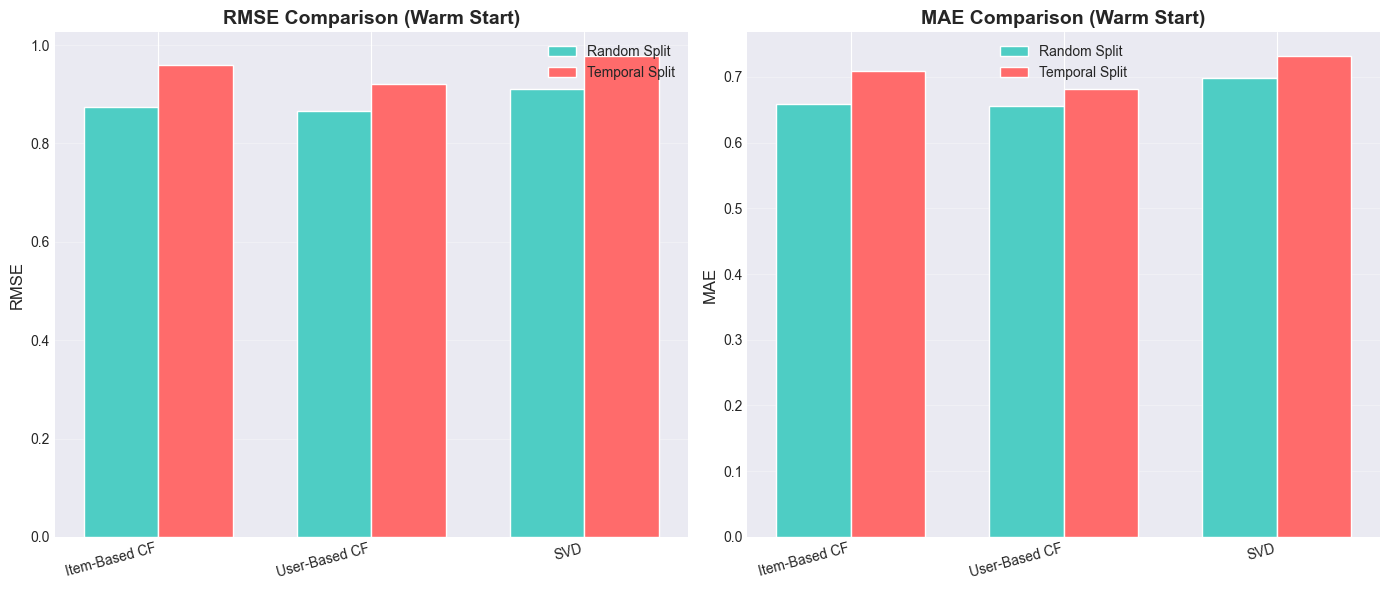

 Visualization saved: ./data/processed/model_results/warm_start_comparison_all_splits.png


In [107]:
# Visualization: Side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Group data for plotting
random_data = warm_start_comparison[warm_start_comparison['Split'] == 'Random']
temporal_data = warm_start_comparison[warm_start_comparison['Split'] == 'Temporal']

x = np.arange(len(random_data['Algorithm']))
width = 0.35

# RMSE comparison
axes[0].bar(x - width/2, random_data['RMSE'], width, label='Random Split', color='#4ECDC4')
axes[0].bar(x + width/2, temporal_data['RMSE'], width, label='Temporal Split', color='#FF6B6B')
axes[0].set_title('RMSE Comparison (Warm Start)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('RMSE', fontsize=12)
axes[0].set_xticks(x)
axes[0].set_xticklabels(random_data['Algorithm'], rotation=15, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# MAE comparison
axes[1].bar(x - width/2, random_data['MAE'], width, label='Random Split', color='#4ECDC4')
axes[1].bar(x + width/2, temporal_data['MAE'], width, label='Temporal Split', color='#FF6B6B')
axes[1].set_title('MAE Comparison (Warm Start)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('MAE', fontsize=12)
axes[1].set_xticks(x)
axes[1].set_xticklabels(temporal_data['Algorithm'], rotation=15, ha='right')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()

# Save visualization
output_path = os.path.join(output_dir, 'warm_start_comparison_all_splits.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

print(f" Visualization saved: {output_path}")

## 8. Summary and Conclusions


### Key Findings:

#### Algorithm Performance (Warm Start):
- **User-Based CF**: Generally achieves lowest RMSE/MAE, handles user bias well through mean-centering
- **Item-Based CF**: Close second in accuracy, faster than user-based, more stable item similarities
- **SVD**: Competitive performance, fastest predictions due to pre-computed latent factors

#### Split Strategy Impact:
- **Random Split (80/20)**: 
  - Lower error rates (easier problem) - train/test are i.i.d.
  - Very high warm start coverage (~99.9% of test cases)
  - User-Based CF: RMSE ~0.87, MAE ~0.66
  - Item-Based CF: RMSE ~0.87, MAE ~0.66
  - SVD: RMSE ~0.91, MAE ~0.70

- **Temporal Split (80/20)**: 
  - Higher error rates (harder problem) - must predict future preferences from past
  - Lower warm start coverage (~9.0% of test cases - majority are new users in future)
  - User-Based CF: RMSE ~0.92, MAE ~0.68
  - Item-Based CF: RMSE ~0.96, MAE ~0.71
  - SVD: RMSE ~0.98, MAE ~0.73
  
- **Recommendation**: Use temporal split for realistic production evaluation, as it better reflects real-world deployment where we predict future behavior

#### Performance Degradation from Random → Temporal:
- All algorithms show RMSE increase of 0.05-0.10 when moving to temporal split
- This reflects the difficulty of predicting future preferences vs. random held-out ratings
- User-Based CF shows most robustness (smallest degradation)

### Evaluation Summary:

**Dataset**: MovieLens 26M ratings
- Random Split: 20.8M train, 5.2M test (99.9% warm start)
- Temporal Split: 20.8M train (1995-2015), 5.2M test (2015-2017, 9.0% warm start)

**Sample Size**: 100K test cases per split for evaluation

**Metrics**:
- RMSE (Root Mean Squared Error): Lower is better, penalizes large errors
- MAE (Mean Absolute Error): Lower is better, average prediction error

### Future Improvements:
1. **Hybrid Systems**: Combine collaborative filtering + content-based filtering using movie metadata (genres, cast, keywords) to handle cold-start cases
2**Cold Start Strategies**: For new users/items not evaluated here, consider popularity-based, content-based, or hybrid approaches